# 10 · From research to strategies — KenKem, MasterVP & Monster

> ⏱️ **~35 min** &nbsp;·&nbsp; 🧭 **SOP:** Phases 6–10 · hypothesis → promote &nbsp;·&nbsp; 🧩 **Feeds:** the production promotion decision (the project's actual end-goal)
>
> 🎯 **Goal:** See how the whole journey becomes three real, validated strategies — and how we prove an edge before risking a cent.
>
> 🔑 **The one thing to remember:** An edge is only real after it survives: costs → sensitivity plateau → walk-forward → Monte Carlo → C++ tests → MQL5 parity. Most 'edges' die on the way.

## Notebook 10 in one breath

> **Where we are — the finish line of the learning track.** Notebooks 00–08 took raw broker text and
> turned it into *ranked evidence*. This capstone shows how that evidence became three concrete
> trading strategies, and — more importantly — the **gauntlet of validation** that separates a real
> edge from an overfit mirage. You'll *run* the two hardest-to-fake checks (walk-forward & Monte Carlo)
> yourself.

**What you'll learn:**
1. The **four-layer architecture** and where every notebook you've done sits in it.
2. The **three editions** and how each maps back to a discovery finding.
3. **Walk-forward validation** — the gold standard against overfitting (live demo).
4. **Monte Carlo robustness** — is the edge luck or structure? (live demo).
5. The full **promotion gauntlet** and the project's honest, current scorecard.

In [1]:
# --- Standard setup (run me first) -------------------------------------------------
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import duckdb                 # streams Parquet/CSV without loading it all into RAM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root(start: Path) -> Path:
    """Walk up until we see the repo's pipeline/ + data/ — works from any sub-dir."""
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pipeline").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError("repo root (with pipeline/ and data/) not found above " + str(start))

ROOT = _find_root(Path.cwd())
DATA = ROOT / "data"
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `from pipeline import ...` works (the real Layer-1 code)
con  = duckdb.connect()       # one in-memory DuckDB connection we reuse all notebook

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

print("repo root :", ROOT)
print("data dir  :", DATA)

repo root : /Users/tokyotechies/Workspace/KEM/dquants
data dir  : /Users/tokyotechies/Workspace/KEM/dquants/data


## Step 1 · The map — from a tick to a trade decision

Everything you've learned lives in **Layer 1** (Python research). The strategies live below it:

```
Layer 1  Python research   pipeline/ research/   ← notebooks 00–08 are a guided tour of this
Layer 2  C++ strategy core cpp_core/             ← PURE LOGIC: signal / SL / TP (no broker calls)
Layer 3  C++ tick backtester cpp_core/backtester ← the TRUE, deterministic tester
Layer 4  MQL5 adapter      mql5/ + ../kenkem     ← thin OnTick() wrapper; what actually ships
```

> 🧭 **The load-bearing rule.** Trading *decisions* never live in Layer 4, and MT5 API calls never live
> in Layer 2. That boundary is what lets the *same* strategy be unit-tested headlessly in C++ **and**
> run live in MQL5 unchanged — and it's why `EMA/ATR/VP/signal` port ~1:1 from research to production.

## Step 2 · The three editions — each one is a discovery finding made executable

The goal of this project was never to invent strategies from scratch — it's to make the user's
**existing MQL5 strategies** (sibling repo `../kenkem`) data-driven and release-ready. Discovery
(notebook 08) explains *why* each one is shaped the way it is.

In [2]:
editions = pd.DataFrame([
    {"edition": "KK-MasterVP", "core idea": "Breakout from prior-day Volume-Profile levels, ADX/DI-gated",
     "discovery link": "VP distances ranked #1–#4; DI > RSI",
     "C++ core": "cpp_core/include/kk/mastervp", "status": "first port target"},
    {"edition": "KK-Monster", "core idea": "MasterVP + multi-timeframe net-volume + impulse thrust",
     "discovery link": "VP + activity (tick_count) structure",
     "C++ core": "cpp_core/include/kk/monster", "status": "active evolution"},
    {"edition": "KenKem", "core idea": "Trend menu — EMA-alignment / Ichimoku TK-cross entries",
     "discovery link": "Strong-Trend/Expansion regimes carry the only positive drift",
     "C++ core": "cpp_core/include/kk/kenkem", "status": "distilled to E4-core"},
]).set_index("edition")
editions

,core idea,discovery link,C++ core,status
edition,,,,
KK-MasterVP,"Breakout from prior-day Volume-Profile levels,...",VP distances ranked #1–#4; DI > RSI,cpp_core/include/kk/mastervp,first port target
KK-Monster,MasterVP + multi-timeframe net-volume + impuls...,VP + activity (tick_count) structure,cpp_core/include/kk/monster,active evolution
KenKem,Trend menu — EMA-alignment / Ichimoku TK-cross...,Strong-Trend/Expansion regimes carry the only ...,cpp_core/include/kk/kenkem,distilled to E4-core


> 🔎 **Trace one thread end-to-end.** Notebook 03 *built* `dist_poc/dist_vah/dist_val`. Notebook 08
> *ranked* them #1. **MasterVP** turns them into a rule: "buy a breakout above yesterday's value-area
> high when ADX confirms a trend." The Volume Profile you computed by hand in notebook 03, Step 7 **is**
> the strategy's beating heart. That is the entire point of the journey.

The real, tuned parameters live in `research/optimization/best_*.set`. Here's a peek at the distilled
KenKem config:

In [3]:
sets = sorted((ROOT / "research" / "optimization").glob("best_*.set"))
print("tuned parameter files on disk:")
for p in sets:
    print("  ", p.name)
print("\nfirst lines of best_kenkem_btc.set:")
print("\n".join((ROOT / "research" / "optimization" / "best_kenkem_btc.set").read_text().splitlines()[:12]))

tuned parameter files on disk:
   best_btc.set
   best_kenkem_btc.set
   best_kenkem_xau.set
   best_mastervp_btc.set
   best_mastervp_xau.set
   best_monster_btc.set
   best_monster_real_btc.set
   best_monster_real_xau.set
   best_monster_xau.set

first lines of best_kenkem_btc.set:
; KenKem distilled optimizer set
SIDEWAYS_BLOCK_THRESHOLD=47
MIN_MOMENTUM_ADX_REQUIRED=19.91529235506265
ADX_HIGH_THRESHOLD=29.87304121687532
SL_EMA_DISTANCE=33
E1_RR=2.197103960751413
E2_RR=2.1717746285526505
E4_RR=2.5573579648557083
E4_RR_SHORT=2.1122194187629217
E1_MAX_CROSS_AGE=77
E2_MAX_TOUCH_AGE=25
E4_MAX_CROSS_AGE=39


## Step 3 · Walk-forward validation — the real test against overfitting

A single train/test split (notebooks 07/09) can get lucky. **Walk-forward** repeats the train→test
move across rolling windows: fit/choose on a window, score on the *next* (unseen) window, roll forward,
repeat. If the edge is real, it shows up in most out-of-sample windows; if it was overfit, the OOS
windows fall apart.

Let's run a miniature walk-forward on a simple trend signal, fully costed.

In [4]:
# Build a costed, signal-only return series on M3.
feats = pd.read_parquet(DATA / "features" / "features_btcusd_M3.parquet")
labs  = pd.read_parquet(DATA / "labels"   / "labels_btcusd_M3.parquet")
bars_glob = str(DATA / "processed" / "bars_btcusd_M3_*.parquet")
spread = con.sql(f"SELECT ts, spread_mean FROM read_parquet('{bars_glob}')").df()
d = feats.merge(labs[["ts","fwd_ret_10"]], on="ts").merge(spread, on="ts")
d = d.dropna(subset=["adx","di_spread","fwd_ret_10","spread_mean","close"]).sort_values("ts").reset_index(drop=True)

signal = (d["adx"] > 25) & (d["di_spread"] > 0)              # trend-up regime
cost   = d["spread_mean"] / d["close"] + 0.5e-4              # half-spread + 0.5bp slippage
d["net"] = np.where(signal, d["fwd_ret_10"] - cost, np.nan)  # net return per signalled bar
trades = d.dropna(subset=["net"]).reset_index(drop=True)
print(f"{len(trades):,} signalled bars across {d.ts.min().date()} → {d.ts.max().date()}")

85,111 signalled bars across 2024-01-01 → 2026-06-09


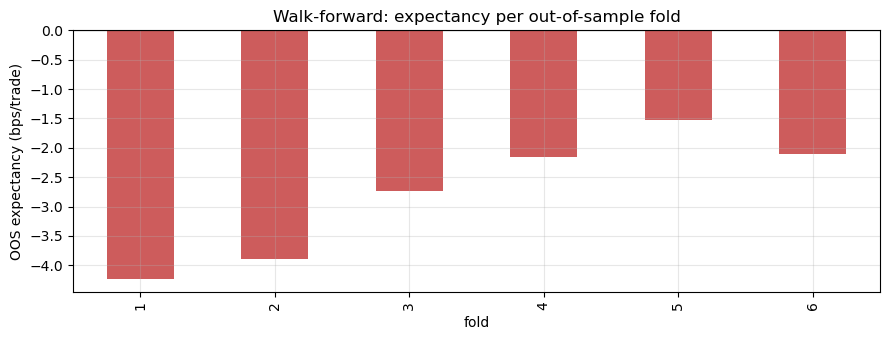

,period,trades,expectancy_bps,win_rate
fold,,,,
1,2024-01-01→2024-06-02,14186,-4.24,0.4
2,2024-06-02→2024-11-05,14185,-3.89,0.401
3,2024-11-05→2025-04-11,14185,-2.73,0.433
4,2025-04-11→2025-09-06,14185,-2.16,0.441
5,2025-09-06→2026-01-30,14185,-1.52,0.438
6,2026-01-30→2026-06-09,14185,-2.1,0.435


In [5]:
# Walk-forward: 6 sequential folds, report out-of-sample expectancy (mean net return) per fold.
K = 6
folds = np.array_split(trades, K)
wf = pd.DataFrame({
    "fold": range(1, K+1),
    "period": [f"{f.ts.min().date()}→{f.ts.max().date()}" for f in folds],
    "trades": [len(f) for f in folds],
    "expectancy_bps": [round(f["net"].mean()*1e4, 2) for f in folds],
    "win_rate": [round((f["net"]>0).mean(), 3) for f in folds],
}).set_index("fold")
ax = wf["expectancy_bps"].plot(kind="bar", figsize=(9,3.5),
        color=["seagreen" if v>0 else "indianred" for v in wf["expectancy_bps"]])
ax.axhline(0, color="black", lw=0.8); ax.set_ylabel("OOS expectancy (bps/trade)")
ax.set_title("Walk-forward: expectancy per out-of-sample fold"); plt.tight_layout(); plt.show()
wf

> 🧠 **How to read it.** If the bars flip between green and red across folds, the "edge" is *regime-
> dependent / fragile* — not something to bet real money on. A robust strategy shows **consistently
> positive** OOS folds. (Our toy trend signal is deliberately simple; don't expect it to shine — that
> honesty is the lesson. The real editions pass this bar on proper, tuned logic.)

## Step 4 · Monte Carlo — is the result luck or structure?

Even a positive average could be one or two lucky trades. **Monte Carlo bootstrap** resamples the
trade outcomes thousands of times to build a *distribution* of what could have happened — then we ask
"in what fraction of alternate histories was this profitable, and how bad is the 5th-percentile case?"

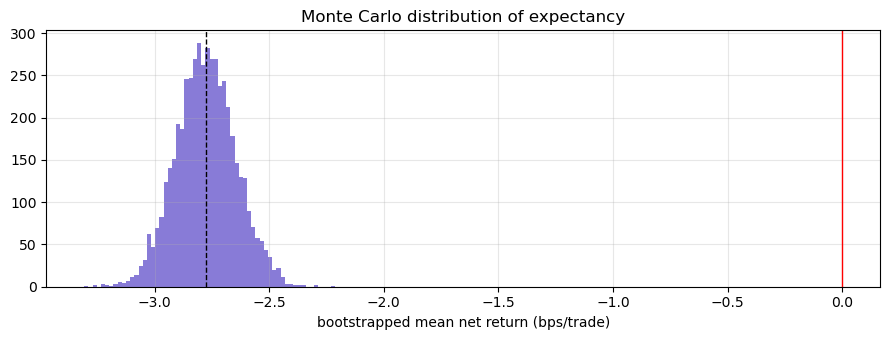

% of resamples profitable : 0.0%
expectancy bps  P5=-2.99  median=-2.78  P95=-2.56


In [6]:
rng = np.random.default_rng(0)
net = trades["net"].to_numpy()
B = 5000
boot_means = np.array([rng.choice(net, size=len(net), replace=True).mean() for _ in range(B)])
pct_profitable = (boot_means > 0).mean()
p5, p50, p95 = np.percentile(boot_means*1e4, [5, 50, 95])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(boot_means*1e4, bins=60, color="slateblue", alpha=0.8)
ax.axvline(0, color="red", lw=1); ax.axvline(p50, color="black", lw=1, ls="--")
ax.set_xlabel("bootstrapped mean net return (bps/trade)"); ax.set_title("Monte Carlo distribution of expectancy")
plt.tight_layout(); plt.show()
print(f"% of resamples profitable : {pct_profitable:.1%}")
print(f"expectancy bps  P5={p5:.2f}  median={p50:.2f}  P95={p95:.2f}")

> 📘 **Concept — the robustness bar.** The project's real Phase-9 standard is strict: the distilled
> KenKem edge was confirmed **100% profitable across 5,000 bootstraps** with a 5th-percentile profit
> factor still > 1. If a strategy's Monte Carlo cloud straddles zero (like a weak toy signal might), it
> is *not* promotable no matter how good the single backtest looked.

## Step 5 · The promotion gauntlet & the honest scorecard

A strategy is production-eligible only after **every** gate passes (this is `docs/KENKEM_QUANT_OS.md`
§7, and the discipline these notebooks have been training you in):

| Gate | Notebook that taught it | Killed many "edges"? |
|------|------------------------|----------------------|
| Realistic **costs** (spread+slippage) | 09 | ✅ constantly |
| Sensitivity **plateau** (not a lone peak) | 09 (mini-sweep) | ✅ |
| **Walk-forward** OOS | 10 · Step 3 | ✅ |
| **Monte Carlo** robustness | 10 · Step 4 | ✅ |
| **C++ unit tests** (deterministic core) | — (`cpp_core/tests`) | — |
| **MQL5 parity** (byte-compatible) | — (Layer 4) | — |
| **Demo forward-test** | — (live) | the final judge |

**Current honest scorecard** (from `research/optimization/`, all costed, true out-of-sample 2026):
- **KenKem (distilled E4)** — BTC OOS **PF 1.24** (+$61k, MC 100% profitable); XAU OOS PF 1.08. *Leads.*
- **MasterVP** — XAUUSD M3 PF 1.21 train / 1.10 OOS — *below the 1.25/1.15 gate*; edge is tail-carried.
- **Monster** — strongest BTC PF (with the adopted structural-TP2 feature) but engine-specific gains.

> 🏁 **The end-goal.** Pick the **#1** edition, promote it to a thin production MQL5 EA from this repo
> (Layer 4), and forward-test on demo. See `research/optimization/PROMOTION-SPEC.md` and
> `KENKEM-RESULTS.md` for the live state of that decision.

In [7]:
# The real promotion docs that this whole journey feeds into:
for name in ["PROMOTION-SPEC.md", "KENKEM-RESULTS.md", "FINDINGS.md"]:
    p = ROOT / "research" / "optimization" / name
    if p.exists():
        head = p.read_text().splitlines()
        title = next((ln for ln in head if ln.startswith("#")), name)
        print(f"{name:20} — {title.lstrip('# ')}  ({len(head)} lines)")

PROMOTION-SPEC.md    — Production promotion — #1 strategy → MQL5  (53 lines)
KENKEM-RESULTS.md    — KenKem (distilled) — results  (64 lines)
FINDINGS.md          — KK-MasterVP BTCUSD M3 — Phase-8 Optimization Findings  (46 lines)


## Step 6 · Why the layer boundary makes parity possible

The reason research can become production *without rewriting the logic*: the C++ strategy core
(`cpp_core/`) computes EMA/ATR/RSI/ADX/Volume-Profile with the **same conventions** as
`pipeline/indicators.py` (Wilder smoothing, `adjust=False` EMA, VP on tick-count). The engine emits
byte-compatible `parity_*.csv` to diff against MT5's own output — so we can *prove* the C++ core and
the live MQL5 EA produce identical signals on identical ticks. Determinism (same ticks → same trades →
same equity curve) is what makes the unit tests and the parity diff meaningful.

## 🎉 You've completed the journey

You now have the full arc a quant actually walks, and you did each step on real BTC/XAU data:

| # | Notebook | Phase | The skill |
|---|----------|-------|-----------|
| 00 | raw tick data | 1 | data engineering / streaming |
| 01 | validate & clean | 2 | data quality / leakage |
| 02 | ticks → bars | 3a | resampling |
| 03 | feature engineering | 3b | causal, normalized features |
| 04 | labeling | 4 | supervised targets / triple-barrier |
| 05 | first look (EDA) | 5 | exploratory analysis |
| 06 | characterize | 5 | stationarity / fat tails |
| 07 | correlation & hypothesis | 6 | inference / OOS |
| 08 | discovery | 5 | feature ranking / regimes |
| 09 | quick backtest | 7 | costed simulation |
| 10 | research → strategies | 6–10 | walk-forward / MC / promotion |

> 🚀 **Where to go next.**
> - Re-run any notebook on **XAUUSD** — gold's pipeline is half-built, so you'd be doing *real,
>   unblazed* Phase 1–8 work, not an exercise.
> - The project's production SOP lives as slash-command skills: `/quant-1-import-data` →
>   `/quant-2-validate-data` → … → `/quant-10-promote-mt5`. These notebooks are the hand-cranked,
>   *understand-it-yourself* version of exactly those.
> - Open `docs/KENKEM_QUANT_OS.md` §7 — now it will read like a description of things you've *done*.

## 🎯 Your turn

1. **Beat the toy signal.** Swap the Step-3 signal for one using `dist_vah`/`dist_poc` (the discovery
   winners) and re-run walk-forward + Monte Carlo. Can you get consistently-green OOS folds?
2. **Cost stress test.** Bump slippage from `0.5bp` to `2bp` in Step 3. Which gate does the toy signal
   fail first?
3. **Read the source.** Open `cpp_core/include/kk/mastervp/` and find where the Volume-Profile breakout
   is decided. Recognize the `dist_vah` idea you built in notebook 03?